In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
stock = yf.Ticker("RELIANCE.NS")
data = stock.history(period = "1y")
print(data.head())

                                  Open         High          Low        Close  \
Date                                                                            
2025-03-06 00:00:00+05:30  1192.238355  1209.120879  1180.435518  1204.788208   
2025-03-07 00:00:00+05:30  1211.162776  1249.808479  1207.178688  1244.828369   
2025-03-10 00:00:00+05:30  1240.047354  1252.995639  1230.485567  1233.473633   
2025-03-11 00:00:00+05:30  1235.067248  1244.529457  1224.858023  1242.338257   
2025-03-12 00:00:00+05:30  1252.995611  1257.975720  1239.051303  1252.049438   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-03-06 00:00:00+05:30  14468014        0.0           0.0  
2025-03-07 00:00:00+05:30  16474965        0.0           0.0  
2025-03-10 00:00:00+05:30  11931051        0.0           0.0  
2025-03-11 00:00:00+05:30  10089838        0.0           0.0  
2025-03-12 00:00:00+05:30  11977555        0.0        

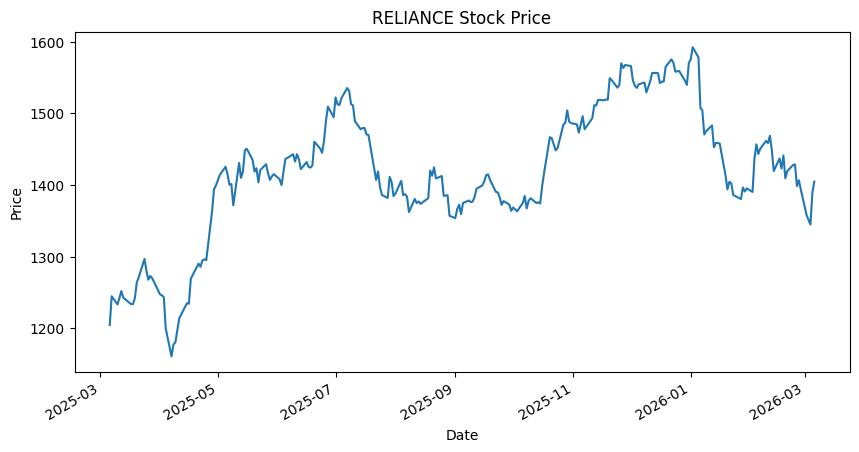

In [3]:
import matplotlib.pyplot as plt
data['Close'].plot(figsize = (10, 5))
plt.title("RELIANCE Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

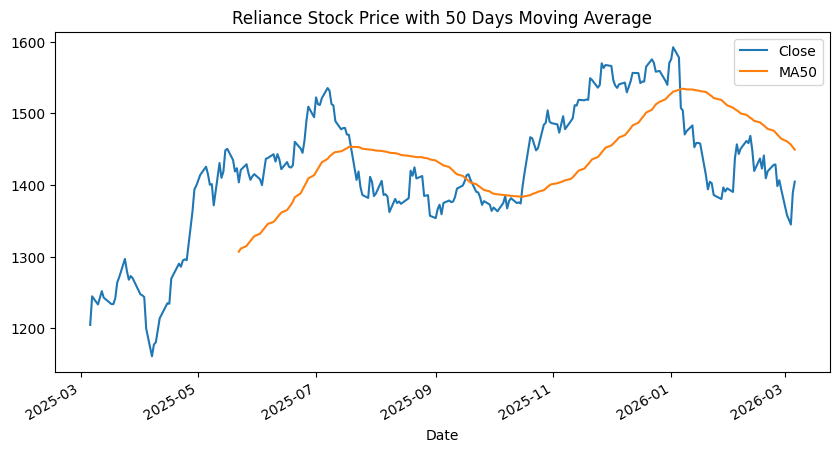

In [6]:
data['MA50'] = data['Close'].rolling(50).mean()
data[['Close','MA50']].plot(figsize = (10, 5))
plt.title("Reliance Stock Price with 50 Days Moving Average")
plt.show()

In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2025-03-06 00:00:00+05:30 to 2026-03-06 00:00:00+05:30
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          248 non-null    float64
 1   High          248 non-null    float64
 2   Low           248 non-null    float64
 3   Close         248 non-null    float64
 4   Volume        248 non-null    int64  
 5   Dividends     248 non-null    float64
 6   Stock Splits  248 non-null    float64
 7   MA50          199 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 17.4 KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA50
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02,248.000000,248.0,199.000000
mean,1419.802103,1431.567855,1408.619593,1420.021011,1.150808e+07,0.022177,0.0,1438.707608
std,91.200589,89.719372,90.929130,89.243910,5.326236e+06,0.349250,0.0,54.534186
min,1127.696009,1166.590715,1110.415052,1161.062744,0.000000e+00,0.000000,0.0,1307.042795
25%,1380.000000,1390.073254,1369.572063,1380.639252,7.906167e+06,0.000000,0.0,1399.517410
50%,1419.665684,1427.748223,1406.840731,1417.318665,1.041997e+07,0.000000,0.0,1440.358884
75%,1483.925018,1492.809477,1470.878995,1480.567627,1.368015e+07,0.000000,0.0,1477.208000
max,1593.000000,1611.800049,1578.199951,1592.300049,3.253897e+07,5.500000,0.0,1534.366001


In [8]:
data.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
MA50,49


In [9]:
close_data = data[['Close']]
close_data.head()

,Close
Date,
2025-03-06 00:00:00+05:30,1204.788208
2025-03-07 00:00:00+05:30,1244.828369
2025-03-10 00:00:00+05:30,1233.473633
2025-03-11 00:00:00+05:30,1242.338257
2025-03-12 00:00:00+05:30,1252.049438


In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(close_data)

In [12]:
scaled_data[:10]

array([[0.10139536],
       [0.19424485],
       [0.16791425],
       [0.18847051],
       [0.21098985],
       [0.18985642],
       [0.1689534 ],
       [0.1689534 ],
       [0.18812403],
       [0.23893706]])

In [13]:
scaled_data.shape

(248, 1)

In [16]:
import numpy as np
X_list = []
y_list = []
for i in range(50, len(scaled_data)):
    X_list.append(scaled_data[i-50:i])
    y_list.append(scaled_data[i])
X = np.array(X_list)
y = np.array(y_list)
print(X.shape)
print(y.shape)

(198, 50, 1)
(198, 1)


In [21]:
!pip install tensorflow keras

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [24]:
model = Sequential()
model.add(LSTM(50, return_sequences = True, input_shape = (X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [26]:
model.fit(X, y, epochs=5, batch_size=32)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.3568
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0326
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0126
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0187
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0087


In [29]:
predictions = model.predict(X)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [30]:
predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y)

In [31]:
predictions[:5]

array([[1440.2771],
       [1441.8894],
       [1443.3368],
       [1444.2343],
       [1444.4865]], dtype=float32)

In [32]:
y_actual[:5]

array([[1421.12426758],
       [1429.09240723],
       [1416.44287109],
       [1407.27954102],
       [1412.16003418]])

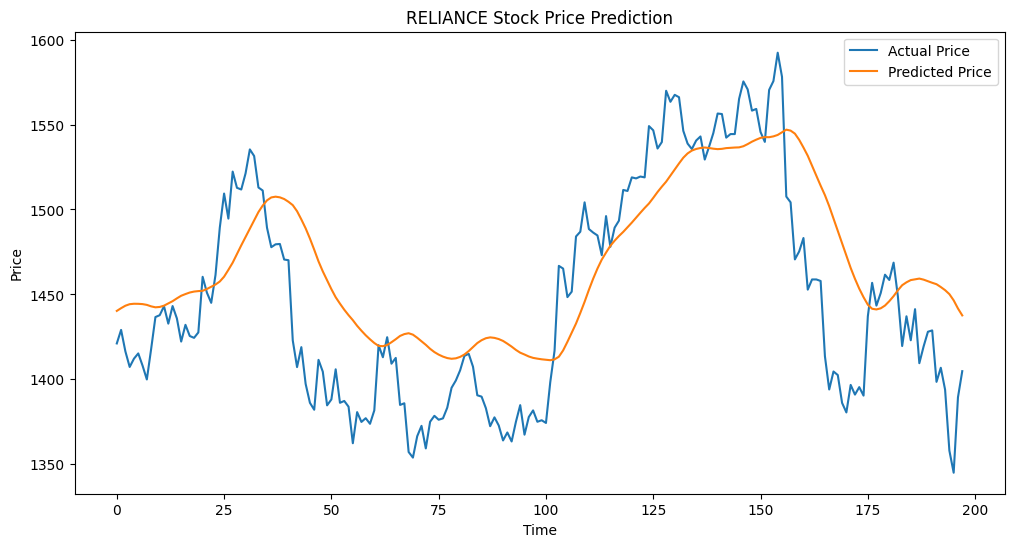

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('RELIANCE Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()

In [34]:
last_50_days = scaled_data[-50:]


In [36]:
import numpy as np
last_50_days = np.reshape(last_50_days,(1, 50, 1))

In [37]:
predicted_price = model.predict(last_50_days)
predicted_price = scaler.inverse_transform(predicted_price)
print("Predicted Next Day Price:" , predicted_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Next Day Price: [[1434.5764]]
